## _Events from Processing_

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### _Load Dataset_

In [6]:
# mu+mu- data (current)
input_dir = 'train_all'

In [7]:
# Find All Input Data Files (hits.csv, cells.csv, particles.csv, truth.csv)
all_files = os.listdir(input_dir)

# Extract File Prefixes (use e.g. xxx-hits.csv)
suffix = '-hits.csv'
file_prefixes = sorted(os.path.join(input_dir, f.replace(suffix, ''))
                       for f in all_files if f.endswith(suffix))

print("Total Events: ", len(file_prefixes))

Total Events:  10000


In [8]:
# test to load an event
event_prefix = file_prefixes[1]

hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

# memory usage
mem_bytes = (hits.memory_usage(index=True).sum() 
             + tubes.memory_usage(index=True).sum() 
             + particles.memory_usage(index=True).sum() 
             + truth.memory_usage(index=True).sum())

print('{} memory usage {:.2f} MB'.format(os.path.basename(event_prefix), mem_bytes / 2**20))

event0000000001 memory usage 0.01 MB


In [9]:
# hits.head()

In [10]:
# tubes.head()

In [11]:
# particles.head()

In [12]:
# truth.head()

## _Event Reader_

- Read a single event at a time using *`SttCSVReader`* class. One can also use *`Event`* class from *`src/event.py`* (under modification).

In [13]:
from src import SttCSVReader, Draw_Reader_Event

In [14]:
input_dir = 'train_all'
reader = SttCSVReader(input_dir, True, True)

In [15]:
event_id = 1

In [16]:
data = reader(event_id)

In [17]:
data.event_file

'/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000000001'

In [18]:
data.hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,event_id,isochrone,skewed,sector_id
0,1,16.618999,-9.595,35.0,9,0,69,1,0.139763,0,3
1,2,17.493700,-9.090,35.0,9,1,178,1,0.198980,0,4
2,3,18.368401,-9.595,35.0,9,2,292,1,0.430639,0,4
3,4,19.243099,-9.090,35.0,9,3,413,1,0.210106,0,4
4,5,20.117800,-8.585,35.0,9,4,540,1,0.004633,0,4


In [19]:
data.tubes.head()

,hit_id,isochrone,depcharge,energyloss,volume_id,layer_id,module_id,skewed,sector_id
0,1,0.139763,151721000.0,151.7210,9,0,69,0,3
1,2,0.198980,51017000.0,51.0170,9,1,178,0,4
2,3,0.430639,158233000.0,158.2330,9,2,292,0,4
3,4,0.210106,120853000.0,120.8530,9,3,413,0,4
4,5,0.004633,90721600.0,90.7216,9,4,540,0,4


In [20]:
data.particles.head(10)

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time,primary,pt,peta
0,7,0.159734,0.060684,1.36980,0.052510,-0.070410,0.016586,-1,15,-211,0.116657,1,0.087834,0.187725
1,9,26.615700,-2.616970,6.28794,0.109018,0.178048,0.049820,1,3,1000010030,3.630260,0,0.208773,0.236423
2,10,26.615700,-2.616970,6.28794,0.065522,0.212454,-0.079217,1,5,1000010030,3.630260,0,0.222328,-0.349167
3,16,26.615700,-2.616970,6.28794,0.012946,-0.362199,0.130007,1,3,1000020040,3.630260,0,0.362430,0.351430
4,17,26.615700,-2.616970,6.28794,0.000020,-0.000058,-0.000032,1,1,11,3.630260,0,0.000061,-0.495570
5,6,0.159734,0.060684,1.36980,0.002950,0.091480,0.459012,1,3,2212,0.116657,1,0.091527,2.315381
6,5,-0.289760,-0.110082,6.09407,-0.107358,-0.009571,0.158487,1,27,211,0.281485,1,0.107784,1.178240


In [21]:
data.truth.head()

,hit_id,tx,ty,tz,tpx,tpy,tpz,weight,particle_id
0,1,16.601801,-9.43210,4.91453,0.038498,0.004041,0.003515,1.0,7
1,2,17.530899,-9.30278,5.00173,0.037515,0.006278,0.004120,1.0,7
2,3,18.261299,-9.15713,5.08071,0.036074,0.008807,0.003997,1.0,7
3,4,19.183001,-8.89799,5.18951,0.034606,0.010729,0.004112,1.0,7
4,5,20.112801,-8.57223,5.30217,0.033031,0.012955,0.004191,1.0,7


In [22]:
data.event.head()

,hit_id,x,y,z,volume_id,layer,module_id,event_id,isochrone,skewed,...,start_time,primary,pt,peta,r,phi,eta,r3,absZ,tpt
0,1,16.618999,-9.595,35.0,9,0,69,1,0.139763,0,...,0.116657,1,0.087834,0.187725,19.189976,-0.523600,1.361974,39.915600,35.0,0.038709
1,2,17.493700,-9.090,35.0,9,1,178,1,0.198980,0,...,0.116657,1,0.087834,0.187725,19.714401,-0.479217,1.338408,40.170357,35.0,0.038036
2,3,18.368401,-9.595,35.0,9,2,292,1,0.430639,0,...,0.116657,1,0.087834,0.187725,20.723469,-0.481379,1.295182,40.675079,35.0,0.037134
3,4,19.243099,-9.090,35.0,9,3,413,1,0.210106,0,...,0.116657,1,0.087834,0.187725,21.282034,-0.441306,1.272376,40.962482,35.0,0.036231
4,5,20.117800,-8.585,35.0,9,4,540,1,0.004633,0,...,0.116657,1,0.087834,0.187725,21.872999,-0.403341,1.249061,41.272606,35.0,0.035481


In [23]:
hits.layer_id.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19], dtype=int32)

In [24]:
data.hits.layer_id.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19], dtype=int32)

In [25]:
data.event.layer.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19], dtype=int32)

## _Detector Layout_

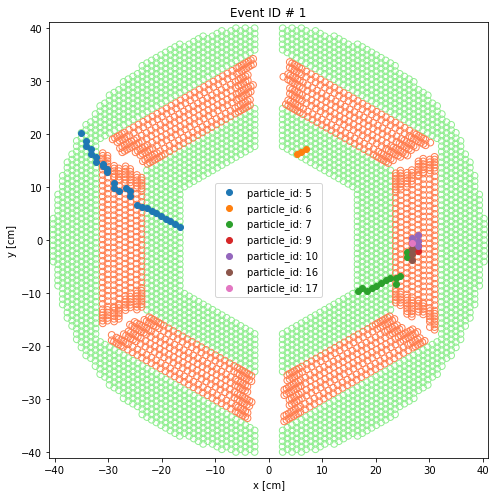

In [26]:
Draw_Reader_Event(data, figsize=(7,7));

## _Split Dataset_

In [ ]:
from 

In [26]:
from LightningModules.GNN.utils.data_utils import load_dataset, split_datasets

In [13]:
trainset, valset, testset = split_datasets(
                                input_dir="run/feature_store/",
                                train_split=[100, 10, 10],
                                pt_background_cut=0,
                                pt_signal_cut=0,
                                noise=True,    
                                seed=1
                            )

all_events:  9958
loaded_events:  120


In [24]:
len(trainset), len(valset), len(testset)

(100, 10, 10)

In [20]:
trainset[2]

Data(x=[109, 3], pid=[109], layers=[109], event_file='/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000001094', hid=[109], pt=[109], modulewise_true_edges=[2, 103], layerwise_true_edges=[2, 196], edge_index=[2, 497], y=[497], y_pid=[497])

In [25]:
event = trainset[0]
event.y == event.y_pid

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

In [21]:
valset[2]

Data(x=[39, 3], pid=[39], layers=[39], event_file='/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000001066', hid=[39], pt=[39], modulewise_true_edges=[2, 37], layerwise_true_edges=[2, 148], edge_index=[2, 148], y=[148], y_pid=[148])

In [22]:
testset[2]

Data(x=[20, 3], pid=[20], layers=[20], event_file='/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000001055', hid=[20], pt=[20], modulewise_true_edges=[2, 19], layerwise_true_edges=[2, 24], edge_index=[2, 24], y=[24], y_pid=[24])

## _Plot True & False Edges_

- processed events from the `feature_store/train`
- code from `notebooks/example_gnn.ipynb`

In [27]:
from src.drawing import detector_layout
from src.utils_math import polar_to_cartesian

In [28]:
event_idx = 8977

In [29]:
inputdir="run/feature_store/train"
proc_files = sorted(glob.glob(os.path.join(inputdir, "*")))
proc_files

[]

In [30]:
proc_files

[]

In [31]:
# event_id
proc_files[event_idx]

IndexError: list index out of range

In [ ]:
feature_data = torch.load(proc_files[event_idx], map_location=device)

In [ ]:
# get spatial coordinates, note: x = [x,y,ir]
r, phi, ir = feature_data.x.T

In [ ]:
# coord. transform, compensate scaling
x, y = polar_to_cartesian(r, phi)
ir = ir*100

In [ ]:
# plot all hits
fig, ax = detector_layout(figsize=(10,10))
ax.scatter(x, y, s=20)

ax.set_title("Azimuthal View of Detector", fontsize=15)
ax.grid(False)
fig.tight_layout()
# fig.savefig('event_{}.png'.format(event_idx))

In [ ]:
# get true_edges
e = feature_data.edge_index
pid = feature_data.pid
true_edges = pid[e[0]] == pid[e[1]]

In [ ]:
# plot only true edges
fig, ax = detector_layout(figsize=(10,10))

ax.plot(x[e[:, true_edges]], y[e[:, true_edges]], c="b")
ax.scatter(x, y, s=20)

ax.set_title("Azimuthal View of Detector", fontsize=15)
ax.grid(False)
fig.tight_layout()
# fig.savefig('true_edges_{}.png'.format(event_idx))

In [ ]:
# plot only false edges
fig, ax = detector_layout(figsize=(10,10))

ax.plot(x[e[:, ~true_edges]], y[e[:, ~true_edges]], c="r")
ax.scatter(x, y, s=20)

ax.set_title("Azimuthal View of Detector", fontsize=15)
ax.grid(False)
fig.tight_layout()
# fig.savefig('false_edges_{}.png'.format(event_idx))

In [ ]:
# plot all edges (true + false), only few false edges
fig, ax = detector_layout(figsize=(10,10))

ax.plot(x[e[:, (~true_edges)][:, 0:-1:5]], y[e[:, (~true_edges)][:, 0:-1:5]], c="r")
ax.scatter(x, y, s=20)

ax.set_title("Azimuthal View of Detector", fontsize=15)
ax.grid(False)
fig.tight_layout()
# fig.savefig('true_edges_less_{}.png'.format(event_idx))

## _Inspect HDFStore_

- See [IO tools (text, CSV, HDF5, …)](https://pandas.pydata.org/docs/user_guide/io.html)

#### HDF5 Store

- read/write using `pd.HDFStore("path/to/*.h5")`
- read/write using `pd.read_hdf()`, `pd.to_hdf()` similar to `pd.read_csv()` and `pd.to_csv()`
    *. `pd.read_hdf()`: Read from the store, close it if we opened it.
- close when finished

In [ ]:
# path to HDF5 Store
hdf5_path = 'run/trkx_reco_eval/eval_particles.h5'

In [ ]:
# Method 1: use context manager to open store
with pd.HDFStore(hdf5_path, 'r') as store:
    print(store.groups())

In [ ]:
# Method 2: Use constructor method. Don't forget to close it using store.close()
store = pd.HDFStore(hdf5_path)

In [ ]:
store.groups()

In [ ]:
# get stored dataframe using group
store.get('data').head()

In [ ]:
# OR, get stored dataframe using group
store['data'].head()

In [ ]:
store.close()

In [ ]:
store.is_open

In [ ]:
# Method 3: Retrieve pandas object stored in h5 file
store = pd.read_hdf(hdf5_path)

In [ ]:
store.head()